# Seasonal Agriculture Performance Analysis


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True


## 3. Load and Inspect the Dataset

In [6]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())


Dataset shape: (4000, 28)

First 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))


Number of rows: 4000
Number of columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [8]:
print("Missing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm_ID values:", df["Farm_ID"].duplicated().sum())


Missing values:


,Missing Values
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


Duplicate rows: 0
Duplicate Farm_ID values: 0


## 4. Data Cleaning and Preparation

In [9]:
text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].str.strip()

duplicate_rows = df.duplicated().sum()
df = df.drop_duplicates().copy()

print("Duplicate rows removed:", duplicate_rows)
print("Shape after duplicate removal:", df.shape)


Duplicate rows removed: 0
Shape after duplicate removal: (4000, 28)


In [10]:
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())
df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(df["Soil_Moisture_pct"].median())

df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(
    df.groupby(["Crop", "Season"])["Yield_Tonnes_Ha"].transform("median")
)

df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(
    df["Yield_Tonnes_Ha"].median()
)

print("Total missing values after cleaning:", df.isnull().sum().sum())
display(df.isnull().sum().to_frame("Missing Values"))


Total missing values after cleaning: 0


,Missing Values
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


## 5. Descriptive / Statistical Analysis

The basic statistics below show the central tendency and spread of the main numeric variables.


In [11]:
numeric_columns = df.select_dtypes(include=np.number).columns

display(df[numeric_columns].describe().T)


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 6. Outlier Investigation

In [12]:
outlier_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Soil_Moisture_pct",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]

outlier_summary = []

for col in outlier_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    count = ((df[col] < lower_limit) | (df[col] > upper_limit)).sum()

    outlier_summary.append([
        col, q1, q3, lower_limit, upper_limit, count
    ])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=[
        "Variable", "Q1", "Q3", "Lower Limit",
        "Upper Limit", "Outlier Count"
    ]
)

display(outlier_summary)


,Variable,Q1,Q3,Lower Limit,Upper Limit,Outlier Count
0,Rainfall_mm,371.575,831.97500,-319.025000,1522.575000,0
1,Avg_Temperature_C,23.900,29.60000,15.350000,38.150000,2
2,Soil_Moisture_pct,21.800,31.20000,7.700000,45.300000,5
3,Fertilizer_kg_ha,143.975,227.20000,19.137500,352.037500,15
4,Pesticide_Litre_ha,3.690,6.40000,-0.375000,10.465000,8
5,Yield_Tonnes_Ha,1.050,2.84000,-1.635000,5.525000,304
6,Profit_INR,-148731.750,216187.75000,-696111.000000,763567.000000,404
7,Water_Used_m3,2268.750,7829.75000,-6072.750000,16171.250000,276
8,Water_Efficiency_t_per_1000m3,1.661,5.15025,-3.572875,10.384125,322


## 7. Univariate Analysis

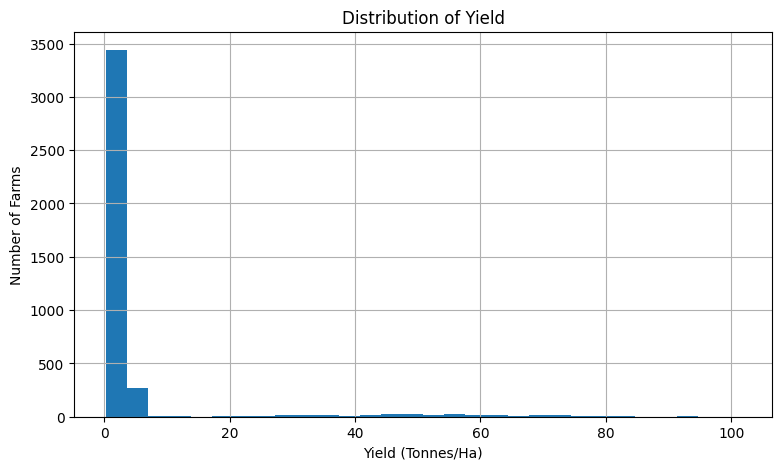

In [13]:
plt.figure()
plt.hist(df["Yield_Tonnes_Ha"], bins=30)
plt.title("Distribution of Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Number of Farms")
plt.show()


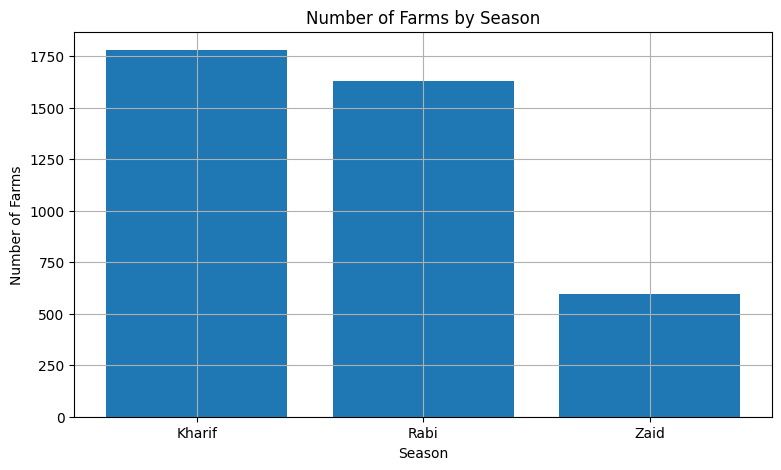

In [14]:
season_counts = df["Season"].value_counts()

plt.figure()
plt.bar(season_counts.index, season_counts.values)
plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.show()


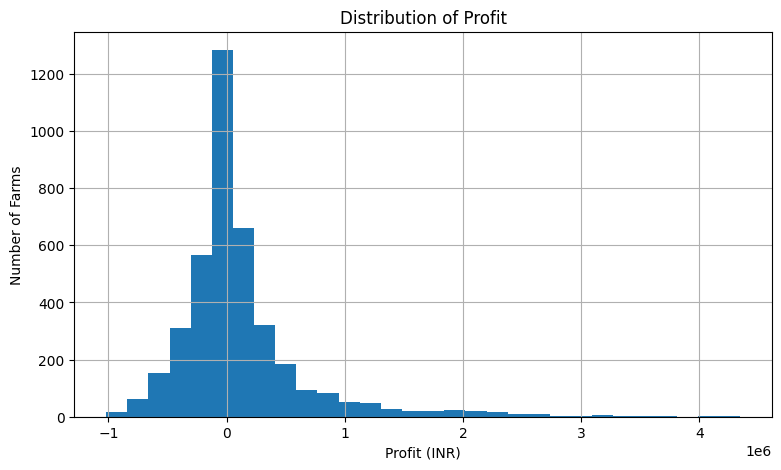

In [15]:
plt.figure()
plt.hist(df["Profit_INR"], bins=30)
plt.title("Distribution of Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Number of Farms")
plt.show()


,Average Yield
Crop,
Pulses,0.917641
Cotton,1.225561
Groundnut,1.318137
Chilli,1.539466
Wheat,2.109813
Rice,2.440899
Maize,2.716851
Sugarcane,46.929049


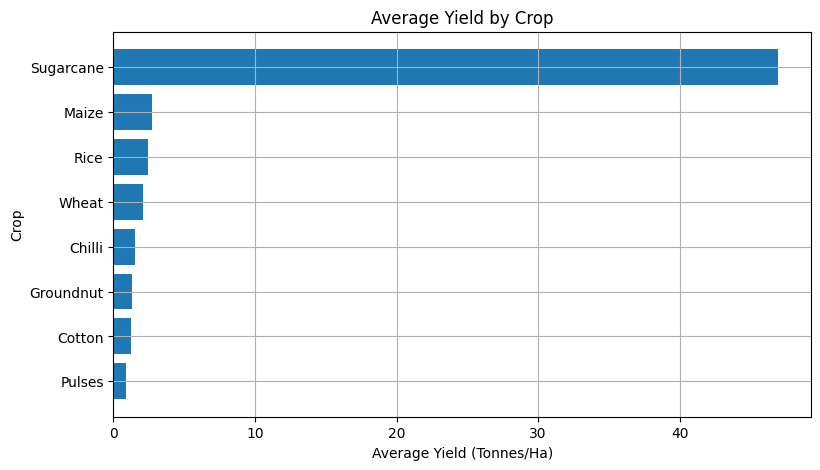

In [16]:
crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values()

display(crop_yield.to_frame("Average Yield"))

plt.figure()
plt.barh(crop_yield.index, crop_yield.values)
plt.title("Average Yield by Crop")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("Crop")
plt.show()


## 8. Bivariate Analysis

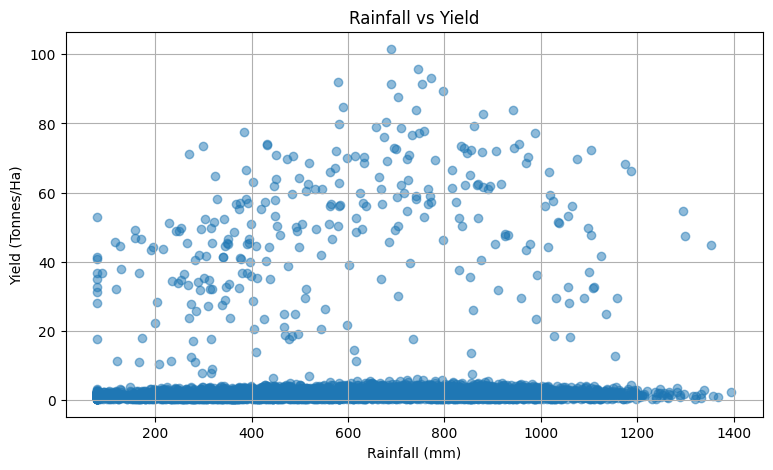

In [17]:
plt.figure()
plt.scatter(df["Rainfall_mm"], df["Yield_Tonnes_Ha"], alpha=0.5)
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()


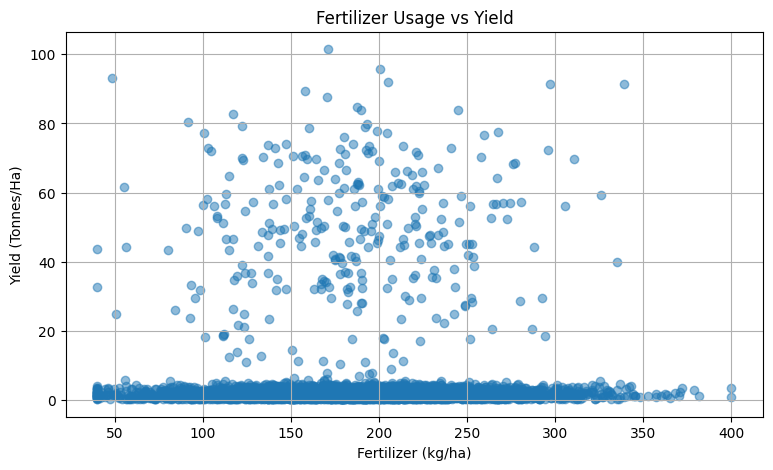

In [18]:
plt.figure()
plt.scatter(df["Fertilizer_kg_ha"], df["Yield_Tonnes_Ha"], alpha=0.5)
plt.title("Fertilizer Usage vs Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()


,Average Profit
Irrigation_Method,
Flood,73354.022901
Rainfed,79050.365034
Sprinkler,91121.079019
Drip,219625.997814


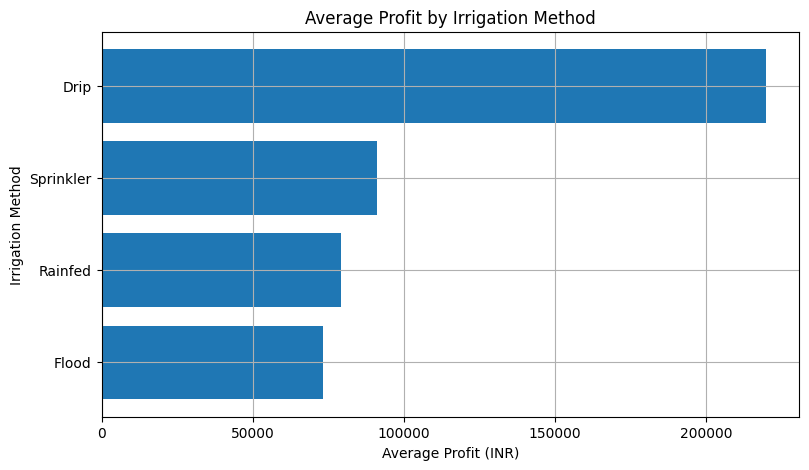

In [19]:
irrigation_profit = (
    df.groupby("Irrigation_Method")["Profit_INR"]
    .mean()
    .sort_values()
)

display(irrigation_profit.to_frame("Average Profit"))

plt.figure()
plt.barh(irrigation_profit.index, irrigation_profit.values)
plt.title("Average Profit by Irrigation Method")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Irrigation Method")
plt.show()


## 9. Multivariate Analysis

In [20]:
crop_season_yield = (
    df.groupby(["Season", "Crop"])["Yield_Tonnes_Ha"]
    .mean()
    .reset_index()
)

display(
    crop_season_yield.sort_values(
        "Yield_Tonnes_Ha", ascending=False
    ).head(10)
)


,Season,Crop,Yield_Tonnes_Ha
6,Kharif,Sugarcane,53.459120
14,Rabi,Sugarcane,43.963953
22,Zaid,Sugarcane,38.423922
3,Kharif,Maize,2.966410
5,Kharif,Rice,2.709268
11,Rabi,Maize,2.617489
13,Rabi,Rice,2.334526
19,Zaid,Maize,2.297262
7,Kharif,Wheat,2.255788
15,Rabi,Wheat,2.059515


In [21]:
yield_pivot = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

display(yield_pivot.round(2))


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.62,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.96,38.42
Wheat,2.26,2.06,1.75


## 10. Correlation Analysis

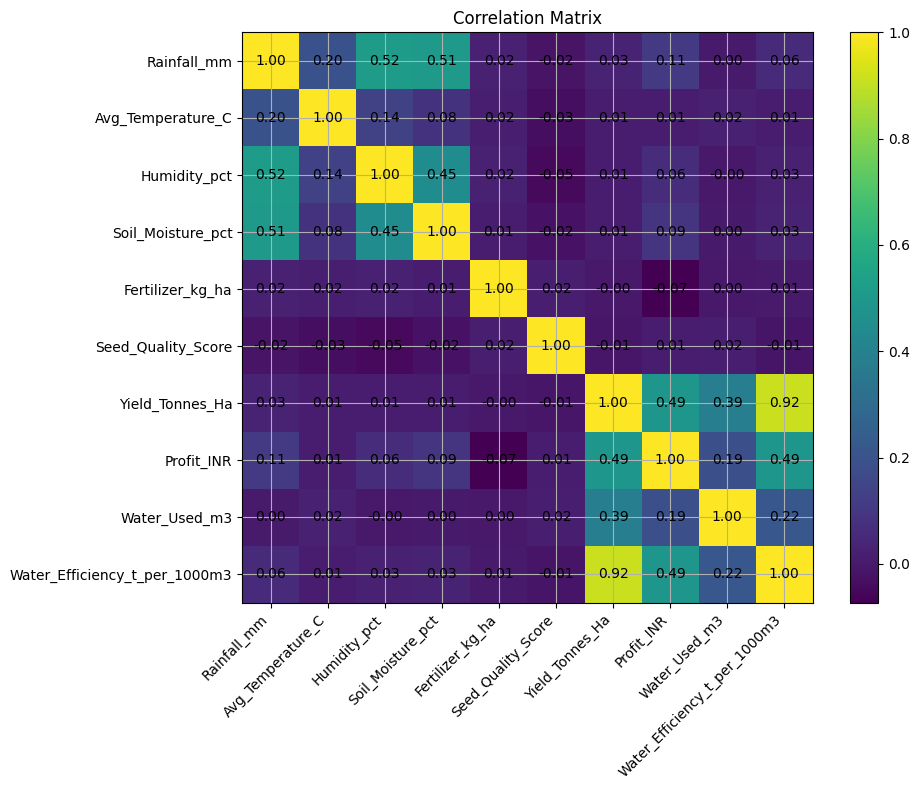

In [22]:
correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Fertilizer_kg_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(10, 8))
image = plt.imshow(correlation_matrix, interpolation="nearest")
plt.colorbar(image)

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        plt.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 11. Seasonal Comparison

In [23]:
season_summary = (
    df.groupby("Season")[
        [
            "Yield_Tonnes_Ha",
            "Rainfall_mm",
            "Water_Used_m3",
            "Water_Efficiency_t_per_1000m3",
            "Profit_INR"
        ]
    ]
    .mean()
    .round(2)
)

display(season_summary)


,Yield_Tonnes_Ha,Rainfall_mm,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Season,,,,,
Kharif,5.63,849.20,6102.20,5.89,178914.65
Rabi,5.09,437.62,5846.99,5.19,87689.47
Zaid,4.64,304.65,6419.89,4.41,-24804.82


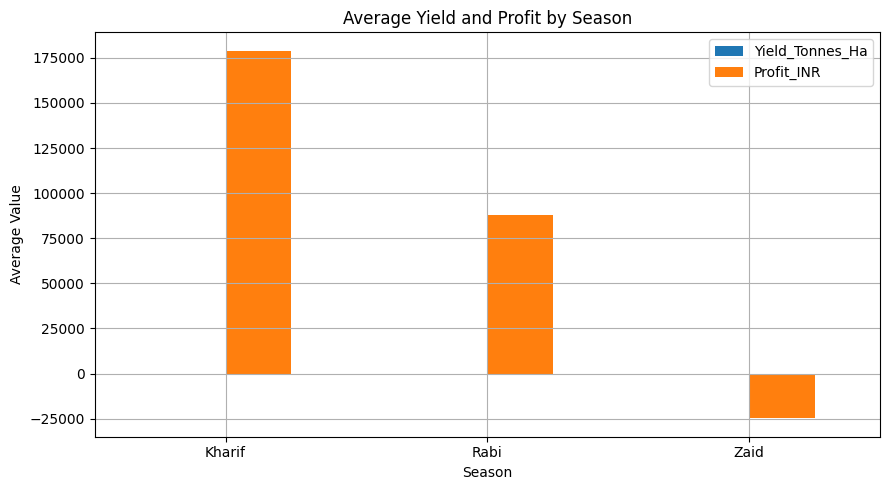

In [24]:
# Average yield and profit across seasons
season_performance = df.groupby("Season")[
    ["Yield_Tonnes_Ha", "Profit_INR"]
].mean()

season_performance.plot(kind="bar")
plt.title("Average Yield and Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [25]:
from scipy.stats import kruskal

kharif_yield = df.loc[df["Season"] == "Kharif", "Yield_Tonnes_Ha"]
rabi_yield = df.loc[df["Season"] == "Rabi", "Yield_Tonnes_Ha"]
zaid_yield = df.loc[df["Season"] == "Zaid", "Yield_Tonnes_Ha"]

statistic, p_value = kruskal(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("Kruskal-Wallis statistic:", round(statistic, 3))
print("p-value:", p_value)

if p_value < 0.05:
    print("The yield distributions differ significantly across seasons.")
else:
    print("No statistically significant difference was detected across seasons.")


Kruskal-Wallis statistic: 70.265
p-value: 5.523734764890478e-16
The yield distributions differ significantly across seasons.


## 12. Student-Designed Analysis 1 — Irrigation and Water Efficiency

In [26]:
irrigation_analysis = (
    df.groupby("Irrigation_Method")[
        [
            "Yield_Tonnes_Ha",
            "Water_Used_m3",
            "Water_Efficiency_t_per_1000m3",
            "Profit_INR"
        ]
    ]
    .mean()
    .sort_values("Water_Efficiency_t_per_1000m3", ascending=False)
    .round(2)
)

display(irrigation_analysis)


,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Rainfed,4.60,3549.55,7.56,79050.37
Drip,6.67,5918.75,6.27,219626.00
Sprinkler,5.16,6208.26,4.67,91121.08
Flood,4.86,8026.47,3.44,73354.02


## 13. Student-Designed Analysis 2 — Crop and Season Performance

In [27]:
crop_season_profit = (
    df.groupby(["Crop", "Season"])[
        ["Yield_Tonnes_Ha", "Profit_INR"]
    ]
    .mean()
    .round(2)
)

display(
    crop_season_profit.sort_values(
        "Profit_INR", ascending=False
    ).head(10)
)


,,Yield_Tonnes_Ha,Profit_INR
Crop,Season,,
Sugarcane,Kharif,53.46,1000790.81
Chilli,Kharif,1.73,954380.42
Sugarcane,Rabi,43.96,731612.86
Chilli,Rabi,1.46,638572.50
Sugarcane,Zaid,38.42,583635.80
Chilli,Zaid,1.18,448659.09
Cotton,Kharif,1.37,216999.55
Groundnut,Kharif,1.48,108265.44
Cotton,Rabi,1.19,107343.59


## 14. Student-Designed Analysis 3 — State-wise Seasonal Performance

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.52,26315.71,-84084.87
Gujarat,217051.33,82846.20,-106929.61
Karnataka,201226.21,70952.61,23310.91
Madhya Pradesh,134242.40,61576.26,209.70
Maharashtra,168801.05,159581.50,-40597.60
Punjab,133779.10,169294.52,62109.69
Tamil Nadu,211303.96,70456.86,-15175.20
Telangana,199668.38,62824.60,-34620.78


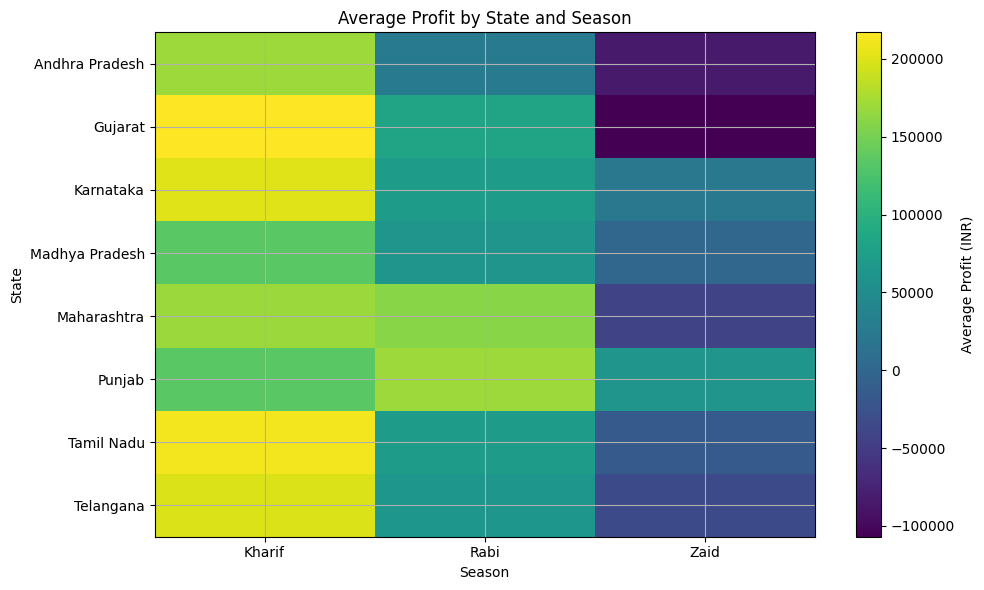

In [28]:
state_season_profit = pd.pivot_table(
    df,
    values="Profit_INR",
    index="State",
    columns="Season",
    aggfunc="mean"
)

display(state_season_profit.round(2))

plt.figure(figsize=(10, 6))
plt.imshow(state_season_profit, aspect="auto", interpolation="nearest")
plt.colorbar(label="Average Profit (INR)")
plt.xticks(
    range(len(state_season_profit.columns)),
    state_season_profit.columns
)
plt.yticks(
    range(len(state_season_profit.index)),
    state_season_profit.index
)
plt.title("Average Profit by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()


## 15. 8 Meaningful Insights

1. **Kharif shows the strongest overall seasonal performance.** Its average yield is about **5.63 tonnes/ha** and its average profit is about **₹178,915**, both higher than Rabi and Zaid.

2. **Zaid has the weakest average economic performance.** Its average profit is about **-₹24,805**, indicating that the average farm in this season records a loss in the dataset.

3. **Sugarcane has a much higher yield than the other crops.** Its average yield is about **46.93 tonnes/ha**, while the other crops are much lower.

4. **Chilli and Sugarcane have the highest average profits among crops.** Their average profits are approximately **₹750,878** and **₹817,188**, respectively.

5. **Drip irrigation has the highest average yield among the irrigation methods.** The observed average is about **6.67 tonnes/ha**, followed by Sprinkler, Flood and Rainfed.

6. **Rainfed farming has the highest average water-efficiency value.** Its observed average is about **7.56 tonnes per 1,000 m³**, although this should not be interpreted as proof that Rainfed causes higher efficiency.

7. **Water efficiency is strongly associated with yield in this dataset.** The correlation between `Water_Efficiency_t_per_1000m3` and `Yield_Tonnes_Ha` is about **0.92**, showing a strong positive relationship.

8. **Crop performance changes with season.** For example, Sugarcane has its highest average yield in **Kharif (about 53.46 tonnes/ha)** and its lowest among its three seasons in **Zaid (about 38.42 tonnes/ha)**.


## 16. Evidence-Based Recommendations

- Give greater attention to **Kharif planning**, because it has the highest average yield and profit in this dataset.
- Investigate the reasons for the **negative average profit in Zaid**, especially production costs, water use and market prices.
- Study **Sugarcane and Chilli** separately because their economic performance is substantially different from most other crops.
- Consider **Drip irrigation** where practical, since it has the highest observed average yield and profit among the listed irrigation methods.
- Monitor **water efficiency** as an important performance indicator because it has a strong relationship with yield in the dataset.
- Compare crop performance within each season before making farm-level decisions rather than relying only on overall crop averages.
- Use state and season comparisons to identify locations where profitability is consistently lower and needs further investigation.
- Treat unusual observations as cases for further study instead of automatically deleting them, particularly where they may represent genuine differences in crops or farming conditions.


## 17. Limitations

- The dataset contains observational records, so relationships do not prove cause and effect.
- Some values were missing and had to be imputed using median-based methods.
- Outliers were investigated but not removed because the project guidelines require investigation and the extreme values may represent genuine agricultural differences.
- The dataset may not include all factors affecting agricultural performance, such as detailed labour costs, local market conditions or farm-management practices.
- Results are specific to the supplied dataset and should not automatically be generalized to all agricultural regions.


## 18. Final Conclusion

The analysis shows clear differences in agricultural performance across seasons, crops, irrigation methods and regions. **Kharif performs strongest on average**, while **Zaid has the weakest average profit**. Crop choice is also important, with Sugarcane and Chilli showing particularly strong economic performance in the supplied data.

The analysis also shows a strong relationship between water efficiency and yield. These findings can support seasonal planning, but farm-level decisions should consider local conditions, costs and market factors as well.
